In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Inspect nwb file

In [2]:
from pynwb import NWBHDF5IO

import sys
sys.path.append('..')

In [3]:
import warnings

nwb_path = r"X:\Personnel\MaryBeth\OpenScope\001709\sub-815059\sub-815059_ses-multiplane-ophys-815059-2025-10-23-11-51-43_ophys.nwb"

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Ignoring cached namespace")
    io = NWBHDF5IO(nwb_path, "r", load_namespaces=True)
    nwb = io.read()

print(nwb)

root abc.NdxEventsNWBFile at 0x2362220280368
Fields:
  acquisition: {
    raw_running_wheel_rotation <class 'pynwb.base.TimeSeries'>,
    running_wheel_signal_voltage <class 'pynwb.base.TimeSeries'>,
    running_wheel_supply_voltage <class 'pynwb.base.TimeSeries'>
  }
  devices: {
    MESO.1 <class 'pynwb.device.Device'>
  }
  experimenter: ["['NSB-1007', 'Jerome Lecoq']"]
  file_create_date: [datetime.datetime(2026, 2, 3, 8, 51, 40, 904295, tzinfo=tzutc())]
  identifier: 40420797-235e-477f-83ff-3055d55ad972
  imaging_planes: {
    VISp_0 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_1 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_2 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_3 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_4 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_5 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_6 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_7 <class 'pynwb.ophys.ImagingPlane'>
  }
  institution: Allen Institute for Neural Dynamics
  intervals: {
    drifting_gratings

In [4]:
rf_stim_table = nwb.intervals["receptive_field_block_presentations"].to_dataframe()
print(rf_stim_table)

# look at the unique stimulus conditions
print()
print("Unique orientations:", rf_stim_table.orientation.unique())
print("Unique spatial frequencies:", rf_stim_table.spatial_frequency.unique())
print("Unique temporal frequencies:", rf_stim_table.temporal_frequency.unique())
print("Unique x positions:", rf_stim_table.x_position.unique())
print("Unique y positions:", rf_stim_table.y_position.unique())

      start_time  stop_time              stim_name    stim_type stim_block  \
id                                                                           
0       18.65377   18.90399  receptive_field_block  GratingStim        0.0   
1       18.90399   19.15421  receptive_field_block  GratingStim        0.0   
2       19.15421   19.40441  receptive_field_block  GratingStim        0.0   
3       19.40441   19.65464  receptive_field_block  GratingStim        0.0   
4       19.65464   19.90483  receptive_field_block  GratingStim        0.0   
...          ...        ...                    ...          ...        ...   
2425   625.46659  625.71679  receptive_field_block  GratingStim        0.0   
2426   625.71679  625.96706  receptive_field_block  GratingStim        0.0   
2427   625.96706  626.21724  receptive_field_block  GratingStim        0.0   
2428   626.21724  626.46745  receptive_field_block  GratingStim        0.0   
2429   626.46745  626.71769  receptive_field_block  GratingStim 

In [5]:
planes = [k for k in nwb.processing.keys() if k.startswith('VISp_')]
print(planes)

['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']


global_roi_ids shape: (153,)
image_masks shape: (153, 512, 512)


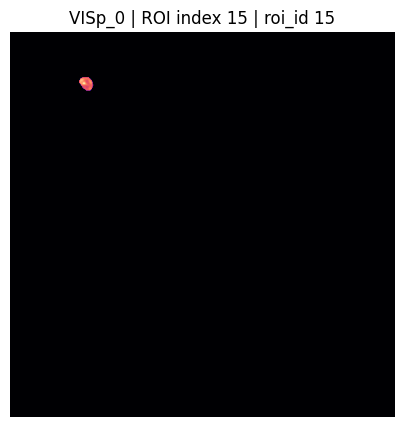

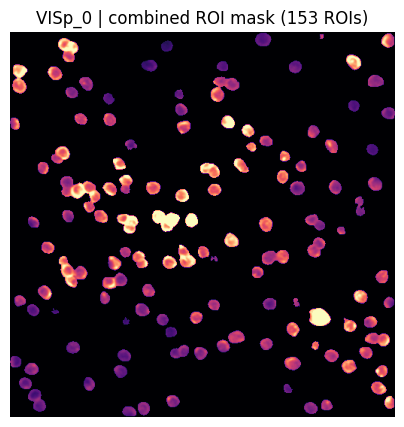

In [6]:
plane = 'VISp_0'
mod = nwb.processing[plane]

roi_table = mod['image_segmentation'].plane_segmentations['roi_table']
global_roi_ids = roi_table.id[:]
print(f"global_roi_ids shape: {global_roi_ids.shape}")

image_masks = roi_table['image_mask'][:]
print(f"image_masks shape: {image_masks.shape}")

# Show a single ROI mask
roi_idx = 15 
plt.figure(figsize=(5, 5))
plt.imshow(image_masks[roi_idx], cmap='magma')
plt.title(f"{plane} | ROI index {roi_idx} | roi_id {global_roi_ids[roi_idx]}")
plt.axis('off')
plt.show()

# Show union of all ROI masks
combined_mask = np.max(image_masks, axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(combined_mask, cmap='magma')
plt.title(f"{plane} | combined ROI mask ({len(global_roi_ids)} ROIs)")
plt.axis('off')
plt.show()

## Write function to get ophys traces

In [7]:
def get_ophys_traces(nwb, plane_names=None):
    if plane_names is None:
        plane_names = [k for k in nwb.processing.keys() if k.startswith('VISp_')]
    
    all_traces = []
    all_roi_info = []
    
    for plane_name in plane_names:
        mod = nwb.processing[plane_name]
        
        series = mod['dff_timeseries'].roi_response_series['dff_timeseries']
        traces_plane = series.data[:]
        plane_timestamps = series.timestamps[:]

        roi_table = mod['image_segmentation'].plane_segmentations['roi_table']
        global_roi_ids = roi_table.id[:]

        all_traces.append(traces_plane)
        for local_idx, roi_id in enumerate(global_roi_ids):
            all_roi_info.append({
                'roi_id': f"{plane_name}_roi{roi_id}",
                'plane': plane_name,
                'local_roi_index': local_idx,
                'raw_roi_id': roi_id,
                'timestamps': plane_timestamps,  
            })

    combined_traces = np.concatenate(all_traces, axis=1)
    roi_info = pd.DataFrame(all_roi_info)
    timestamps = roi_info.iloc[0]['timestamps']

    return combined_traces, timestamps, roi_info

## Get traces for all planes

In [8]:
planes = [k for k in nwb.processing.keys() if k.startswith('VISp_')]
print(planes)

['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']


In [9]:
print(f"  Extracting dF/F traces...")
traces, timestamps, roi_info = get_ophys_traces(nwb, plane_names=planes)

print(f"  traces shape: {traces.shape}, n_rois: {len(roi_info)}")

roi_info = roi_info.copy()

  Extracting dF/F traces...
  traces shape: (38455, 812), n_rois: 812


In [10]:
print(timestamps[:5])

[18.10151 18.207   18.31249 18.41798 18.52347]


In [11]:
print(rf_stim_table.shape)
print()
print((rf_stim_table.stop_time - rf_stim_table.start_time).mean())
print(1 / np.mean(np.diff(timestamps)))  # frame rate
print()
print(rf_stim_table.groupby(['x_position', 'y_position']).size().describe())
print()
print(rf_stim_table.head())

(2430, 13)

0.2502320658436214
9.478395846057897

count    81.0
mean     30.0
std       0.0
min      30.0
25%      30.0
50%      30.0
75%      30.0
max      30.0
dtype: float64

    start_time  stop_time              stim_name    stim_type stim_block  \
id                                                                         
0     18.65377   18.90399  receptive_field_block  GratingStim        0.0   
1     18.90399   19.15421  receptive_field_block  GratingStim        0.0   
2     19.15421   19.40441  receptive_field_block  GratingStim        0.0   
3     19.40441   19.65464  receptive_field_block  GratingStim        0.0   
4     19.65464   19.90483  receptive_field_block  GratingStim        0.0   

   temporal_frequency spatial_frequency orientation contrast x_position  \
id                                                                        
0                 4.0              0.08         0.0      0.8      -30.0   
1                 4.0              0.08        90.0      0.8    

In [12]:
print(traces.mean())
(traces > 0).mean()

0.04183195


0.5401034284202698

In [13]:
# Should be ~3x the number of unique positions
print(len(rf_stim_table))
print()
print(rf_stim_table.groupby(['x_position', 'y_position']).size())
print()

2430

x_position  y_position
-10.0       -10.0         30
            -20.0         30
            -30.0         30
            -40.0         30
            0.0           30
                          ..
40.0        0.0           30
            10.0          30
            20.0          30
            30.0          30
            40.0          30
Length: 81, dtype: int64



In [14]:
# What stimulus parameters do you have?
print(rf_stim_table.columns.tolist())
print(rf_stim_table[['x_position','y_position','orientation','contrast']].head(10))
print(rf_stim_table[['x_position','y_position']].nunique())

# How many unique stimulus positions?
print(rf_stim_table[['x_position','y_position']].drop_duplicates().shape)

# Time range of stimuli vs traces
print("stim start:", rf_stim_table['start_time'].min())
print("stim end:", rf_stim_table['stop_time'].max())
print("n stim presentations:", len(rf_stim_table))

io.close()

['start_time', 'stop_time', 'stim_name', 'stim_type', 'stim_block', 'temporal_frequency', 'spatial_frequency', 'orientation', 'contrast', 'x_position', 'y_position', 'stim_index', 'timeseries']
   x_position y_position orientation contrast
id                                           
0       -30.0       20.0         0.0      0.8
1        10.0       40.0        90.0      0.8
2        10.0       40.0        90.0      0.8
3       -30.0      -20.0        90.0      0.8
4       -30.0       10.0        45.0      0.8
5        30.0       40.0         0.0      0.8
6        10.0       10.0         0.0      0.8
7        40.0       10.0         0.0      0.8
8        10.0      -10.0        45.0      0.8
9        20.0      -30.0        90.0      0.8
x_position    9
y_position    9
dtype: int64
(81, 2)
stim start: 18.65377
stim end: 626.7176900000001
n stim presentations: 2430


## Write function to build RF

In [15]:
def get_rf(xs, ys, rf_stim_table, orientation=None, timestamps=None, responses=None,
           t_start=0.05, t_end=0.25):
    
    # create empty array
    unit_rf = np.zeros([ys.size, xs.size])
    # loop over every x position
    for xi, x in enumerate(xs):
        # loop over every y position
        for yi, y in enumerate(ys):
            
            # get all stimulus presentations for this position
            stim_rows = rf_stim_table[
                (rf_stim_table.x_position.astype(float) == x) & 
                (rf_stim_table.y_position.astype(float) == y)
            ]
            if orientation is not None:
                stim_rows = stim_rows[stim_rows.orientation == orientation]
            # start with an empty mask for all time points
            all_mask = np.zeros(len(timestamps), dtype=bool)
            
            # loop over each stimulus presentation and build a mask of time points that fall within the response window
            for _, row in stim_rows.iterrows():
                all_mask |= (timestamps >= row.start_time + t_start) & (timestamps < row.start_time + t_end)
            
            # average the df/F values that fall within the response windows marked as true
            unit_rf[yi, xi] = np.mean(responses[all_mask]) if all_mask.any() else 0
          
    return unit_rf

def get_rf_with_baseline(xs, ys, rf_stim_table, orientation=None, timestamps=None, responses=None,
           t_start=0.1, t_end=0.6,
           baseline_start=-0.2, baseline_end=0.0):
    """
    Build a spatial RF map by averaging dF/F within a response window relative
    to stimulus onset, with optional pre-stimulus baseline subtraction.

    Parameters
    ----------
    t_start, t_end : float
        Response window relative to stimulus onset (seconds).
        FIX: widened from (0.05, 0.25) to (0.1, 0.6) to capture the GCaMP
        transient, which typically peaks 300-700ms post-stimulus.
    baseline_start, baseline_end : float
        Pre-stimulus window for baseline subtraction (seconds relative to onset).
        FIX: added baseline subtraction to remove trial-by-trial DC offsets.
    """
    unit_rf = np.zeros([ys.size, xs.size])

    for xi, x in enumerate(xs):
        for yi, y in enumerate(ys):

            stim_rows = rf_stim_table[
                (rf_stim_table.x_position.astype(float) == x) &
                (rf_stim_table.y_position.astype(float) == y)
            ]
            if orientation is not None:
                stim_rows = stim_rows[stim_rows.orientation == orientation]

            trial_responses = []
            for _, row in stim_rows.iterrows():
                t0 = row.start_time

                # response window
                resp_mask = (timestamps >= t0 + t_start) & (timestamps < t0 + t_end)
                if not resp_mask.any():
                    continue

                # FIX: baseline subtraction — mean dF/F in pre-stim window
                base_mask = (timestamps >= t0 + baseline_start) & (timestamps < t0 + baseline_end)
                baseline = np.mean(responses[base_mask]) if base_mask.any() else 0.0

                trial_responses.append(np.mean(responses[resp_mask]) - baseline)

            unit_rf[yi, xi] = np.mean(trial_responses) if trial_responses else 0.0

    return unit_rf

## Build RFs for all mice

In [16]:
from gaussian_filtering import fit_gaussian_to_rf
from pathlib import Path

In [17]:
data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")
output_dir = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ophys\results")

mouse_dirs = [d for d in data_dir.iterdir() if d.is_dir() and d.name.startswith('sub-')]
print(f"Found {len(mouse_dirs)} mouse directories")

Found 8 mouse directories


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.8.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


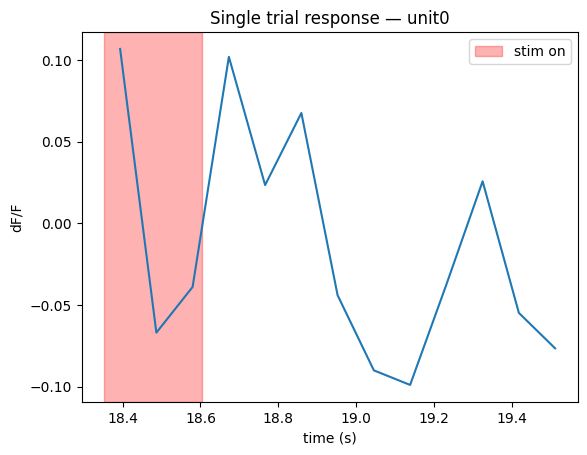

In [ ]:
# Run this on one mouse first
io = NWBHDF5IO(str(mouse_dirs[0] / list(mouse_dirs[0].glob("*.nwb"))[0]), "r", load_namespaces=True)
nwb = io.read()
traces, timestamps, roi_info = get_ophys_traces(nwb)
rf_stim_table = nwb.intervals["receptive_field_block_presentations"].to_dataframe()

# choose unit to analyze
unit = 0

# Check a single trial
trial = rf_stim_table.iloc[unit]
mask = (timestamps >= trial.start_time) & (timestamps < trial.stop_time + 1.0)
plt.plot(timestamps[mask], traces[mask, unit])
plt.axvspan(trial.start_time, trial.stop_time, alpha=0.3, color='red', label='stim on')
plt.xlabel('time (s)')
plt.ylabel('dF/F')
plt.title(f'Single trial response — unit {unit}')
plt.legend()
plt.show()

In [ ]:
baseline = True

unit_records_all = []

for mouse_idx, mouse_dir in enumerate(mouse_dirs, 1):
    mouse_name = mouse_dir.name
    print("=" * 80)
    print(f"Processing Mouse {mouse_idx}/{len(mouse_dirs)}: {mouse_name}")
    print("=" * 80)

    nwb_files = list(mouse_dir.glob("*.nwb"))
    if not nwb_files:
        print(f"  No NWB files found in {mouse_dir}, skipping.")
        continue

    for nwb_path in nwb_files:
        print(f"  Processing NWB file: {nwb_path.name}")
        io = None
        try:
            io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
            nwb = io.read()

            traces, timestamps, roi_info = get_ophys_traces(nwb)
            print(f"  traces shape: {traces.shape}, timestamps: {timestamps[0]:.2f} → {timestamps[-1]:.2f}")

            # RF block
            print(f"  Computing RFs...")
            rf_stim_table = nwb.intervals["receptive_field_block_presentations"].to_dataframe()
            xs = np.sort(np.array(list(set(rf_stim_table.x_position.astype(float)))))
            ys = np.sort(np.array(list(set(rf_stim_table.y_position.astype(float)))))

            # Sanity check overlap
            overlap = ((timestamps >= rf_stim_table.start_time.min()) &
                       (timestamps <= rf_stim_table.stop_time.max())).sum()
            print(f"  Frames during RF stim block: {overlap}")

            uid_to_rf = {}

            for col_idx, (local_idx, row) in enumerate(roi_info.iterrows()):
                uid = row['roi_id']
                plane = row['plane']
                dff_trace = traces[:, col_idx]

                # FIX: use per-plane timestamps for this ROI
                plane_timestamps = row['timestamps']

                orientations = [None] + list(rf_stim_table.orientation.unique())
                for ori in orientations:
                    ori_label = str(ori) if ori is not None else 'all'

                    if not baseline:
                        rf = get_rf(xs=xs, ys=ys, timestamps=plane_timestamps,
                                     rf_stim_table=rf_stim_table,
                                     orientation=ori, responses=dff_trace)
                        save_dir = mouse_dir / 'RFs' / nwb_path.stem / plane / ori_label
                    else: 
                        rf = get_rf_with_baseline(xs=xs, ys=ys, timestamps=plane_timestamps,
                                     rf_stim_table=rf_stim_table,
                                     orientation=ori, responses=dff_trace)
                        save_dir = mouse_dir / 'RFs_with_baseline' / nwb_path.stem / plane / ori_label

                    # FIX: store each (unit, orientation) separately
                    uid_to_rf[(uid, ori_label)] = {'rf': rf, 'xs': xs, 'ys': ys}

                    
                    save_dir.mkdir(parents=True, exist_ok=True)

                    popt, r_squared, _ = fit_gaussian_to_rf(rf)
                    if popt is not None:
                        x_pos = float(np.interp(popt[1], np.arange(len(xs)), xs))
                        y_pos = float(np.interp(popt[2], np.arange(len(ys)), ys))
                        fit_status = 'success'
                    else:
                        x_pos, y_pos = np.nan, np.nan
                        fit_status = 'failed'
                        print(f"  Fit failed for {uid} (orientation={ori_label})")

                    plt.imshow(rf, extent=(xs.min(), xs.max(), ys.min(), ys.max()), origin='lower')
                    plt.colorbar(label='dF/F')
                    plt.scatter(x_pos, y_pos, color='red', marker='x', label='RF Center')
                    plt.xlabel('X position (deg)')
                    plt.ylabel('Y position (deg)')
                    plt.title(f'{uid} ori={ori_label} (R²={r_squared:.3f})' if r_squared is not None else f'RF map: {uid} ori={ori_label} (no fit)')
                    plt.savefig(save_dir / f'RF_map_{uid}.png', dpi=150, bbox_inches='tight')
                    plt.close()

                    unit_records_all.append({
                        'roi_id': uid,
                        'mouse_name': mouse_name,
                        'nwb_file': nwb_path.name,
                        'plane': plane,
                        'orientation': ori_label,
                        'fit_status': fit_status,
                        'rf_center_x': x_pos if popt is not None else np.nan,
                        'rf_center_y': y_pos if popt is not None else np.nan,
                        'r_squared': float(r_squared) if popt is not None else np.nan,
                        'rf_amplitude': float(popt[0]) if popt is not None else np.nan,
                        'rf_sigma_x': float(popt[3]) if popt is not None else np.nan,
                        'rf_sigma_y': float(popt[4]) if popt is not None else np.nan,
                        'mean_dff': float(np.mean(dff_trace)),
                        'max_dff': float(np.max(dff_trace)),
                        'frac_positive': float((dff_trace > 0).mean()),
                    })

        except Exception as e:
            import traceback
            print(f"  ERROR on {mouse_name} / {nwb_path.name}: {e}")
            traceback.print_exc()

        finally:
            if io is not None:
                io.close()
                print(f"  NWB file closed: {nwb_path.name}")

units_df = pd.DataFrame(unit_records_all)
units_df.to_csv(output_dir / 'rf_unit_info.csv', index=False)


Processing Mouse 1/8: sub-809092
  Processing NWB file: sub-809092_ses-multiplane-ophys-809092-2025-10-01-12-34-23_ophys.nwb


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.8.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


  traces shape: (43579, 1099), timestamps: 16.81 → 4073.67
  Computing RFs...
  Frames during RF stim block: 6531
